In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from keras.models import Sequential
from keras.layers import Conv2D,MaxPool2D,Flatten,Dense

In [ ]:
os.listdir("/content/drive/MyDrive/DL/Brain_Tumor")

['Training', 'Testing']

In [ ]:
os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training")

['glioma', 'pituitary', 'notumor', 'meningioma']

In [ ]:
os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing")

['pituitary', 'notumor', 'meningioma', 'glioma']

In [ ]:
glioma_training=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training/glioma"))
glioma_training

1287

In [ ]:
pituitary_training=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training/pituitary"))
pituitary_training


1349

In [ ]:
notumor_training=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training/notumor"))
notumor_training

1574

In [ ]:
meningioma_training=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training/meningioma"))
meningioma_training

1319

In [ ]:
glioma_testing=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing/glioma"))
glioma_testing

300

In [ ]:
pituitary_testing=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing/pituitary"))
pituitary_testing


300

In [ ]:
notumor_testing=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing/notumor"))
notumor_testing

405

In [ ]:
meningioma_testing=len(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing/meningioma"))
meningioma_testing

306

In [ ]:
training_classes=sorted(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Training"))
training_classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
testing_classes=sorted(os.listdir("/content/drive/MyDrive/DL/Brain_Tumor/Testing"))
testing_classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
x_train=[]
y_train=[]
datadir="/content/drive/MyDrive/DL/Brain_Tumor/Training"
categories=['glioma','meningioma','notumor','pituitary']

In [ ]:
for i in categories:
  path=os.path.join(datadir,i)
  for img in os.listdir(path):
    img_path=os.path.join(path,img)
    img_arr=imread(img_path)
    img_res=resize(img_arr,(150,150,1))
    x_train.append(img_res)
    y_train.append(categories.index(i))

In [ ]:
x_test=[]
y_test=[]
datadir1="/content/drive/MyDrive/DL/Brain_Tumor/Testing"
categories1=['glioma','meningioma','notumor','pituitary']

In [ ]:
for i in categories1:
  path=os.path.join(datadir1,i)
  for img1 in os.listdir(path):
    img_path=os.path.join(path,img1)
    img_arr=imread(img_path)
    img_res=resize(img_arr,(150,150,1))
    x_test.append(img_res)
    y_test.append(categories1.index(i))

In [ ]:
len(x_test)

1311

In [ ]:
len(x_train)

5529

In [ ]:
len(y_train)

5529

In [ ]:
len(y_test)

1311

In [ ]:
x_train=np.array(x_train)
y_train=np.array(y_train)

In [ ]:
x_test=np.array(x_test)
y_test=np.array(y_test)

In [ ]:
#model creation
model=Sequential()
model.add(Conv2D(32,(3,3),input_shape=(150,150,1),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Flatten())
model.add(Dense(100,activation='relu'))
model.add(Dense(50,activation='relu'))
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile Model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,epochs=40,batch_size=400)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.4109 - loss: 2.1467
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.6681 - loss: 0.8507
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.7385 - loss: 0.6753
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.7911 - loss: 0.5558
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.8323 - loss: 0.4631
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8624 - loss: 0.3799
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.8996 - loss: 0.3074
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9049 - loss: 0.2721
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.9152 - loss: 0.2443
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.9179 - loss: 0.2260


In [ ]:
model.evaluate(x_test,y_test,batch_size=20)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8734 - loss: 0.3381


[0.33813878893852234, 0.873379111289978]

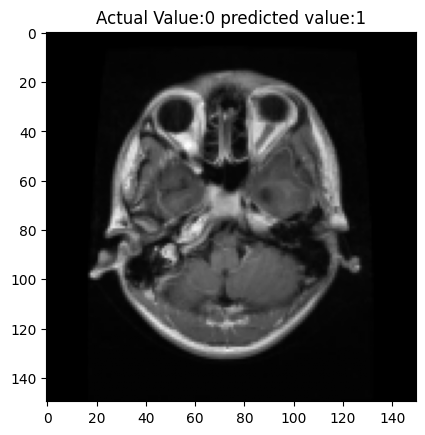

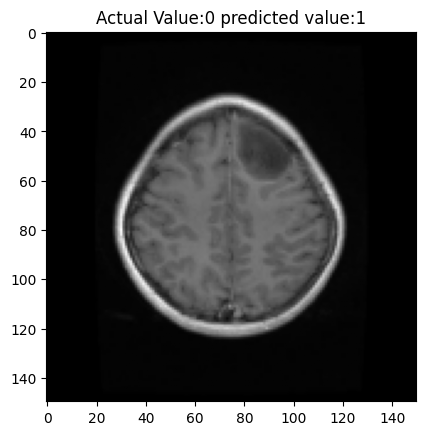

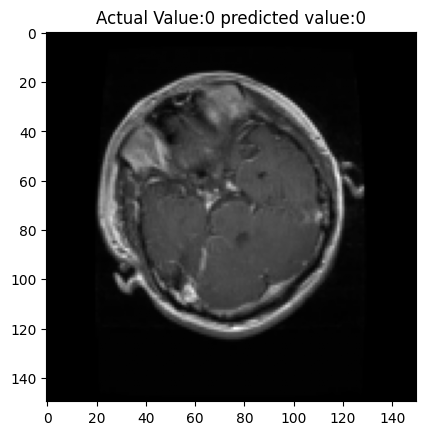

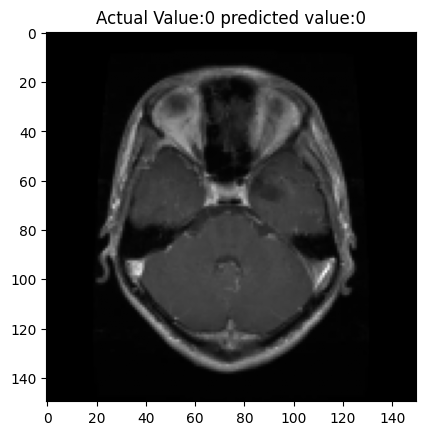

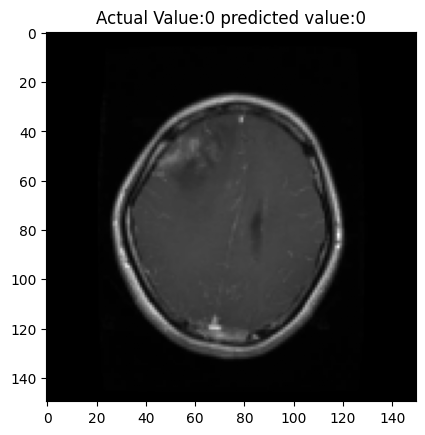

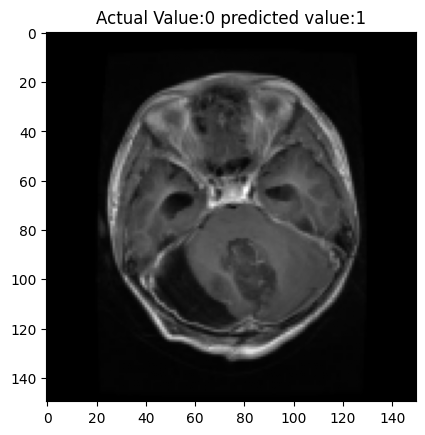

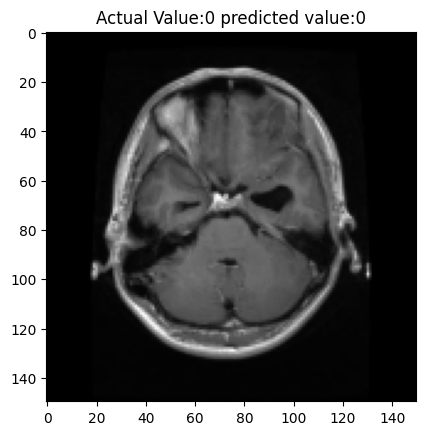

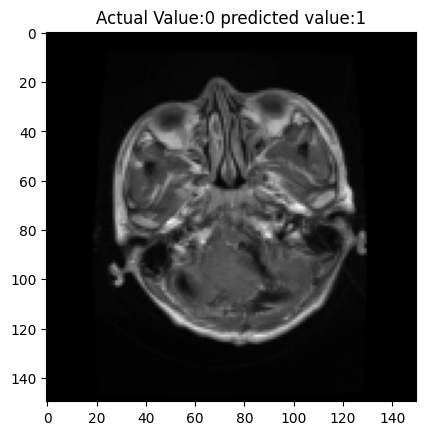

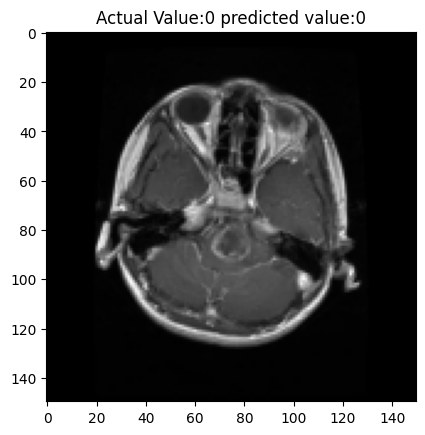

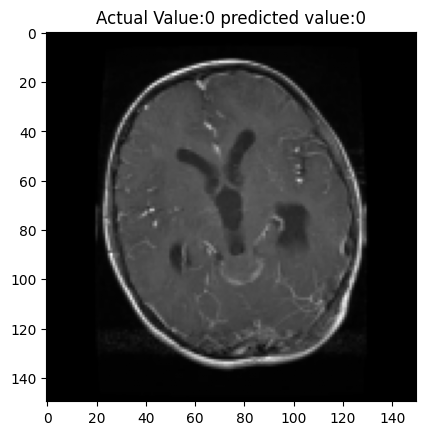

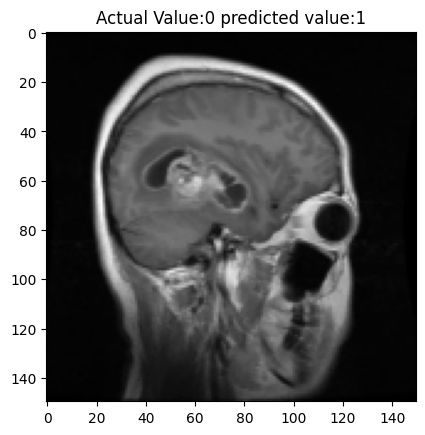

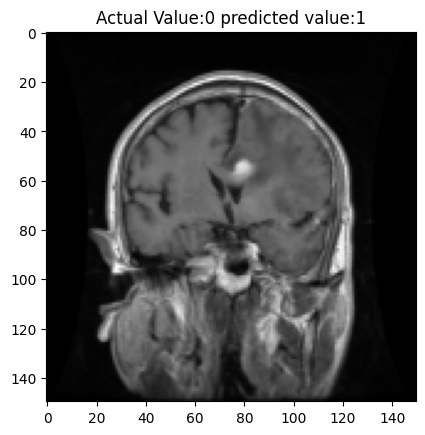

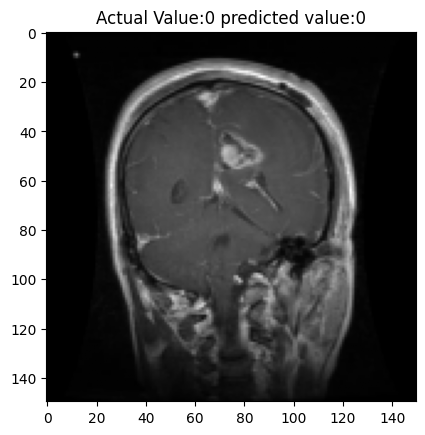

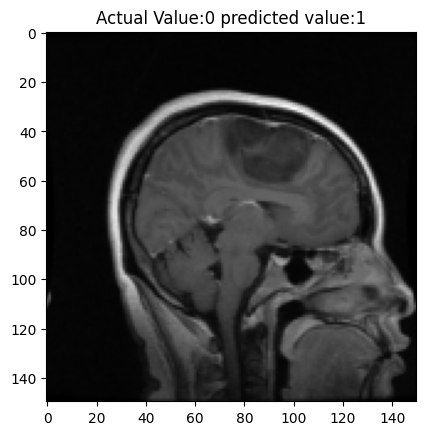

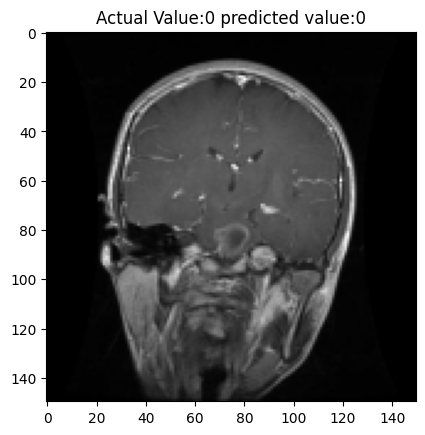

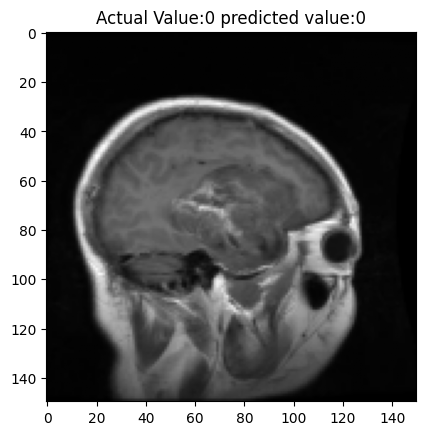

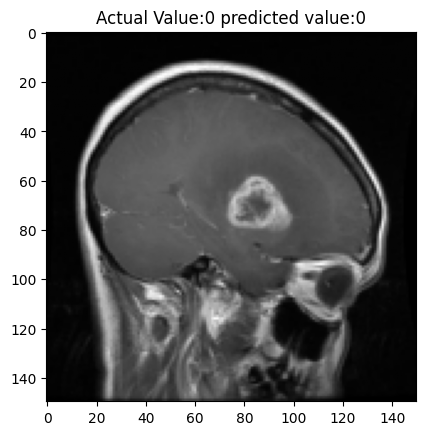

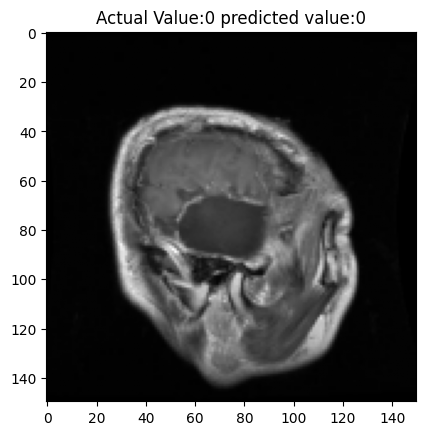

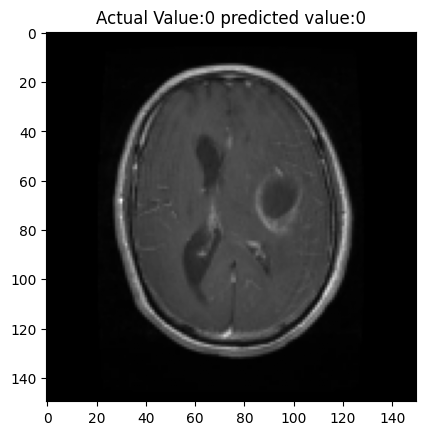

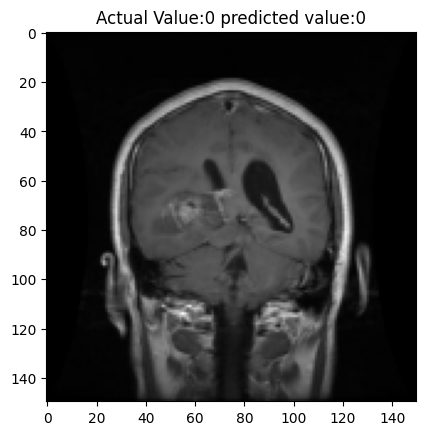

In [ ]:
for i in range(20):
  pred=model.predict(x_test[i].reshape(1,150,150,1),verbose=0)
  pred_final=np.argmax(pred)
  plt.imshow(x_test[i],cmap='gray')
  plt.title(f"Actual Value:{y_test[i]} predicted value:{pred_final}")
  plt.show()

In [ ]:
img="/content/brain.png"
img1=imread(img)
img2=resize(img1,(1,150,150,1))
y_pred=model.predict(img2)
y_pred1=np.argmax(y_pred)
y_pred1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


np.int64(2)

In [ ]:
categories[y_pred1]

'notumor'